In [1]:
import pandas as pd
import numpy as np

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

### Load Dataset

In [2]:
df = pd.read_csv(
    "../data/processed/feature_engineered_data.csv"
)

### Datatype Conversion

In [3]:
df['date'] = pd.to_datetime(df['date'])

### Sanity Check

In [4]:
df.shape

(1885, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1885 entries, 0 to 1884
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   d                1885 non-null   object        
 1   sales            1885 non-null   int64         
 2   date             1885 non-null   datetime64[ns]
 3   year             1885 non-null   int64         
 4   month            1885 non-null   int64         
 5   quarter          1885 non-null   int64         
 6   day              1885 non-null   int64         
 7   weekday          1885 non-null   int64         
 8   weekofyear       1885 non-null   int64         
 9   is_weekend       1885 non-null   int64         
 10  is_event         1885 non-null   int64         
 11  event_type_1     1885 non-null   object        
 12  sales_lag_7      1885 non-null   float64       
 13  sales_lag_14     1885 non-null   float64       
 14  sales_lag_28     1885 non-null   float64

In [6]:
df.head()

,d,sales,date,year,month,quarter,day,weekday,weekofyear,is_weekend,is_event,event_type_1,sales_lag_7,sales_lag_14,sales_lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,rolling_std_7,rolling_std_28
0,d_29,29908,2011-02-26,2011,2,1,26,5,8,1,0,No_Event,31689.0,34833.0,32631.0,24143.142857,25112.214286,26238.678571,4576.628250,5320.795395
1,d_30,28707,2011-02-27,2011,2,1,27,6,8,1,0,No_Event,29283.0,36380.0,31749.0,23888.714286,24760.428571,26141.428571,4113.263859,5223.630967
2,d_31,21240,2011-02-28,2011,2,1,28,0,9,0,0,No_Event,23966.0,21804.0,23783.0,23806.428571,24212.357143,26032.785714,3991.319742,5133.540619
3,d_32,22872,2011-03-01,2011,3,1,1,1,9,0,0,No_Event,20501.0,24070.0,25412.0,23417.000000,24172.071429,25941.964286,4104.536312,5196.921314
4,d_33,22046,2011-03-02,2011,3,1,2,2,9,0,0,No_Event,20757.0,21443.0,19146.0,23755.714286,24086.500000,25851.250000,3917.358537,5228.586542


### Prophet Dataset

In [7]:
prophet_df = df[['date','sales']].copy()

prophet_df.columns = ['ds','y']

prophet_df.head()

,ds,y
0,2011-02-26,29908
1,2011-02-27,28707
2,2011-02-28,21240
3,2011-03-01,22872
4,2011-03-02,22046


In [8]:
train = prophet_df[:-90]

test = prophet_df[-90:]

In [9]:
train.shape
test.shape

(90, 2)

In [10]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train)

23:23:12 - cmdstanpy - INFO - Chain [1] start processing
23:23:13 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
prophet_df = df[['date','sales']].copy()
prophet_df.columns = ['ds','y']

### Create Future Dates

In [12]:
future = model.make_future_dataframe(
    periods=90
)

future.tail()

,ds
1880,2016-04-20
1881,2016-04-21
1882,2016-04-22
1883,2016-04-23
1884,2016-04-24


### Generate Forecast

In [13]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2011-02-26,23158.221860,26678.770362,35635.263030,23158.221860,23158.221860,8123.582673,8123.582673,8123.582673,7092.027323,7092.027323,7092.027323,1031.555350,1031.555350,1031.555350,0.0,0.0,0.0,31281.804533
1,2011-02-27,23176.774492,26689.288991,35408.656076,23176.774492,23176.774492,7665.071749,7665.071749,7665.071749,6683.622582,6683.622582,6683.622582,981.449167,981.449167,981.449167,0.0,0.0,0.0,30841.846241
2,2011-02-28,23195.327124,17908.565504,27162.004116,23195.327124,23195.327124,-492.543004,-492.543004,-492.543004,-1411.299798,-1411.299798,-1411.299798,918.756794,918.756794,918.756794,0.0,0.0,0.0,22702.784120
3,2011-03-01,23213.879756,15792.470207,24283.704902,23213.879756,23213.879756,-3066.846246,-3066.846246,-3066.846246,-3912.063275,-3912.063275,-3912.063275,845.217029,845.217029,845.217029,0.0,0.0,0.0,20147.033510
4,2011-03-02,23232.432388,15304.996016,24197.010737,23232.432388,23232.432388,-3484.985006,-3484.985006,-3484.985006,-4247.785567,-4247.785567,-4247.785567,762.800560,762.800560,762.800560,0.0,0.0,0.0,19747.447382


In [14]:
forecast[
    ['ds','yhat','yhat_lower','yhat_upper']
].tail()

,ds,yhat,yhat_lower,yhat_upper
1880,2016-04-20,35779.091967,31464.952156,39922.353116
1881,2016-04-21,35869.582463,31595.948633,40172.928415
1882,2016-04-22,39851.914479,35086.417809,43985.181033
1883,2016-04-23,47001.701861,42054.450635,51380.564439
1884,2016-04-24,46564.421149,42310.079314,50894.969364


### Forecast Visualization

NameError: name 'plt' is not defined

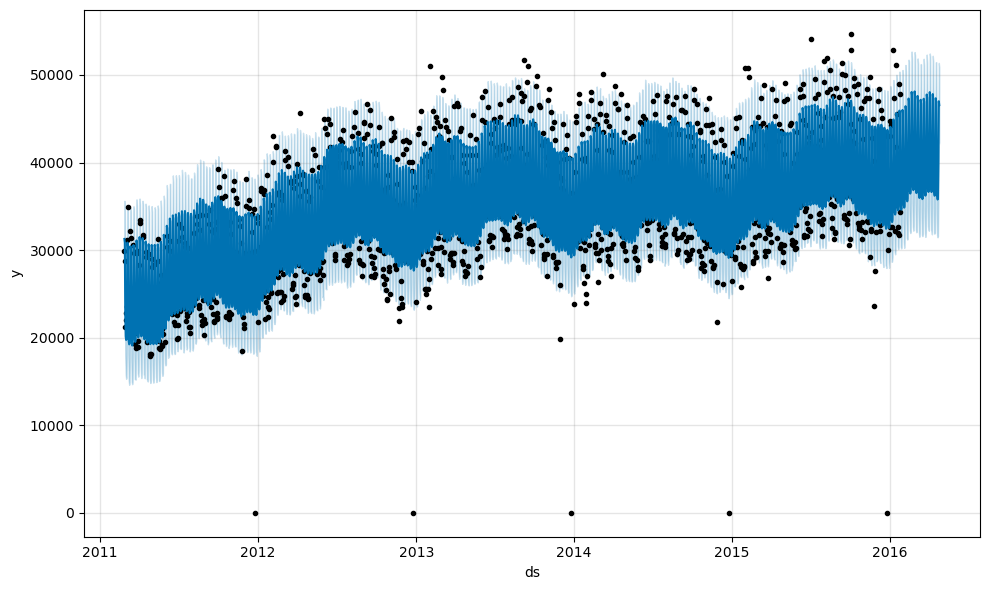

In [15]:
fig = model.plot(forecast)

plt.title(
    "Retail Demand Forecast",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    "../screenshots/prophet_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Prophet Components

NameError: name 'plt' is not defined

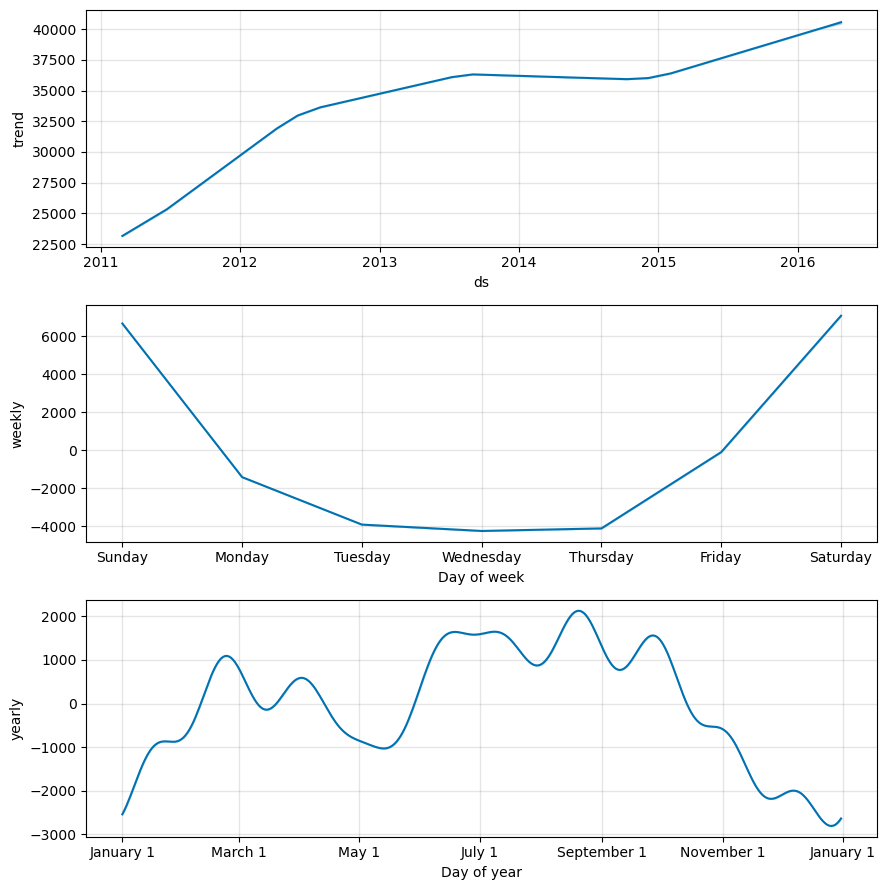

In [16]:
fig = model.plot_components(forecast)

plt.savefig(
    "../screenshots/prophet_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Evaluate Model

In [17]:
forecast_test = forecast.tail(90)

In [18]:
forecast_test.shape

(90, 19)

In [19]:
test.shape

(90, 2)

### MAE

In [20]:
mae = mean_absolute_error(
    test['y'],
    forecast_test['yhat']
)

mae

2829.920377174824

### RMSE

In [21]:
rmse = np.sqrt(
    mean_squared_error(
        test['y'],
        forecast_test['yhat']
    )
)

rmse

3607.8813362621354

In [22]:
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE : 2829.92
RMSE: 3607.88


### Actual vs Predicted Chart

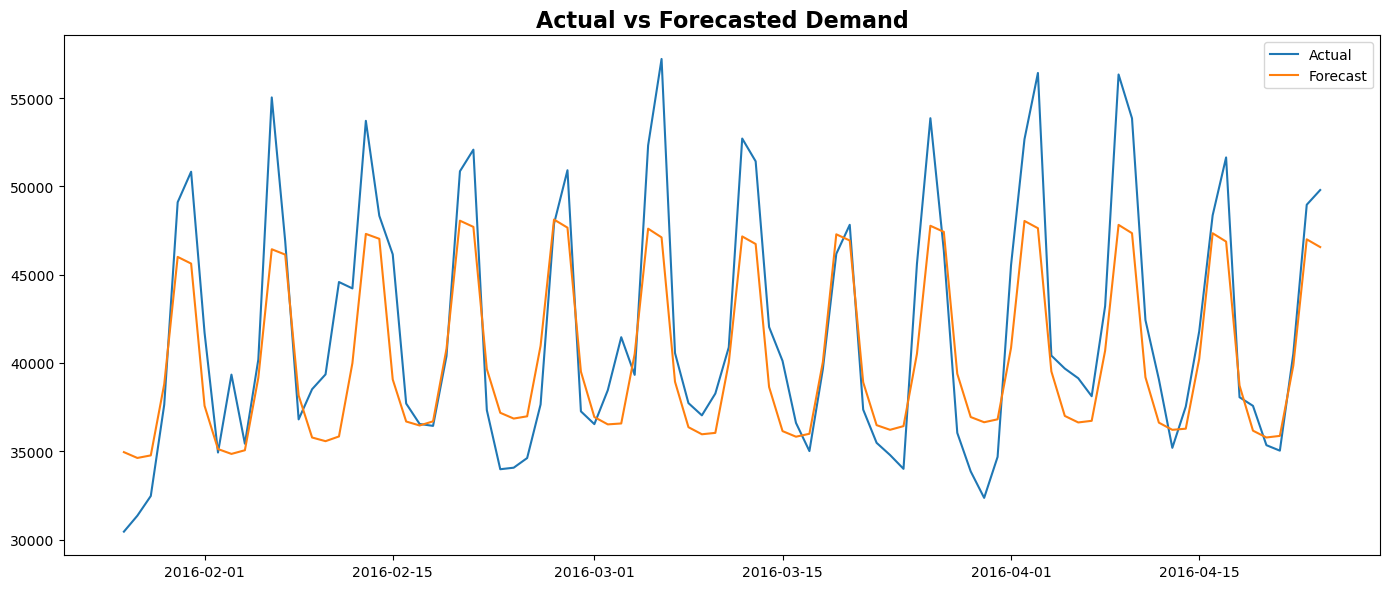

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))

plt.plot(
    test['ds'],
    test['y'],
    label='Actual'
)

plt.plot(
    forecast_test['ds'],
    forecast_test['yhat'],
    label='Forecast'
)

plt.title(
    "Actual vs Forecasted Demand",
    fontsize=16,
    fontweight='bold'
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../screenshots/actual_vs_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
forecast_output = forecast[['ds','yhat']].copy()

forecast_output.to_csv(
    "../data/processed/forecast_results.csv",
    index=False
)

In [25]:
forecast_output.head()

,ds,yhat
0,2011-02-26,31281.804533
1,2011-02-27,30841.846241
2,2011-02-28,22702.784120
3,2011-03-01,20147.033510
4,2011-03-02,19747.447382


In [26]:
import os

os.listdir("../data/processed")

['feature_engineered_data.csv', 'forecast_results.csv']

In [27]:
comparison = pd.DataFrame({
    'date': test['ds'],
    'actual_sales': test['y'],
    'forecast_sales': forecast_test['yhat']
})

comparison.head()

,date,actual_sales,forecast_sales
1795,2016-01-26,30446,34948.905601
1796,2016-01-27,31349,34620.021849
1797,2016-01-28,32466,34764.964258
1798,2016-01-29,37639,38801.496208
1799,2016-01-30,49104,46007.051658


In [29]:
comparison.to_csv(
    '../data/processed/actual_vs_forecast.csv',
    index=False
)